<a href="https://colab.research.google.com/github/zahraptsl/STAT3-bioactivity-analysis/blob/main/CDD_ML_Part_2_Exploratory_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Bioinformatics Project - Computational Drug Discovery [Part 2] Exploratory Data Analysis**

## **Load bioactivity data**

In [ ]:
# mount googledrive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:
import pandas as pd

In [3]:
# 1. Install RDKit
!pip install rdkit

import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski

# 2. Baca dataset curated STAT3 yang sudah dibuat sebelumnya
df = pd.read_csv('/content/STAT3_03_bioactivity_data_curated.csv')
df.head()

,molecule_chembl_id,canonical_smiles,standard_value,class
0,CHEMBL160849,CC(=O)N[C@@H](Cc1ccc(CP(=O)(O)O)cc1)C(=O)N[C@@...,8000.0,active
1,CHEMBL158446,CC(=O)N[C@@H](Cc1ccc(-c2nn[nH]n2)cc1)C(=O)N[C@...,6000.0,active
2,CHEMBL160733,CSCC[C@H](NC(=O)[C@H](CCC(N)=O)NC(=O)[C@H]1CCC...,400.0,active
3,CHEMBL156407,CC(=O)N[C@H](Cc1ccc(OP(=O)(O)O)cc1)C(=O)N[C@H]...,800.0,active
4,CHEMBL157314,CC(=O)N[C@H](Cc1ccc(OP(=O)(O)O)cc1)C(=O)N[C@H]...,6000.0,active


## **Calculate Lipinski descriptors**
Christopher Lipinski, a scientist at Pfizer, came up with a set of rule-of-thumb for evaluating the **druglikeness** of compounds. Such druglikeness is based on the Absorption, Distribution, Metabolism and Excretion (ADME) that is also known as the pharmacokinetic profile. Lipinski analyzed all orally active FDA-approved drugs in the formulation of what is to be known as the **Rule-of-Five** or **Lipinski's Rule**.

The Lipinski's Rule stated the following:
* Molecular weight < 500 Dalton
* Octanol-water partition coefficient (LogP) < 5
* Hydrogen bond donors < 5
* Hydrogen bond acceptors < 10

### **Import libraries**

In [ ]:
!pip install rdkit-pypi

In [4]:
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski

### **Calculate descriptors**

In [5]:
# Inspired by: https://codeocean.com/explore/capsules?query=tag:data-curation

def lipinski(smiles, verbose=False):

    moldata= []
    for elem in smiles:
        mol=Chem.MolFromSmiles(elem)
        moldata.append(mol)

    baseData= np.arange(1,1)
    i=0
    for mol in moldata:

        desc_MolWt = Descriptors.MolWt(mol)
        desc_MolLogP = Descriptors.MolLogP(mol)
        desc_NumHDonors = Lipinski.NumHDonors(mol)
        desc_NumHAcceptors = Lipinski.NumHAcceptors(mol)

        row = np.array([desc_MolWt,
                        desc_MolLogP,
                        desc_NumHDonors,
                        desc_NumHAcceptors])

        if(i==0):
            baseData=row
        else:
            baseData=np.vstack([baseData, row])
        i=i+1

    columnNames=["MW","LogP","NumHDonors","NumHAcceptors"]
    descriptors = pd.DataFrame(data=baseData,columns=columnNames)

    return descriptors

In [6]:
df_lipinski = lipinski(df.canonical_smiles)

### **Combine DataFrames**

Let's take a look at the 2 DataFrames that will be combined.

In [7]:
df_lipinski

,MW,LogP,NumHDonors,NumHAcceptors
0,838.897,-1.82460,10.0,10.0
1,812.930,-2.32220,9.0,12.0
2,923.988,-2.26580,11.0,13.0
3,810.843,-1.39170,9.0,10.0
4,841.853,-1.43150,10.0,11.0
...,...,...,...,...
1490,2058.439,-2.04098,20.0,27.0
1491,2050.361,0.54272,16.0,25.0
1492,2167.655,0.36162,17.0,26.0
1493,2024.469,0.20882,19.0,24.0


In [8]:
df

,molecule_chembl_id,canonical_smiles,standard_value,class
0,CHEMBL160849,CC(=O)N[C@@H](Cc1ccc(CP(=O)(O)O)cc1)C(=O)N[C@@...,8000.000,active
1,CHEMBL158446,CC(=O)N[C@@H](Cc1ccc(-c2nn[nH]n2)cc1)C(=O)N[C@...,6000.000,active
2,CHEMBL160733,CSCC[C@H](NC(=O)[C@H](CCC(N)=O)NC(=O)[C@H]1CCC...,400.000,active
3,CHEMBL156407,CC(=O)N[C@H](Cc1ccc(OP(=O)(O)O)cc1)C(=O)N[C@H]...,800.000,active
4,CHEMBL157314,CC(=O)N[C@H](Cc1ccc(OP(=O)(O)O)cc1)C(=O)N[C@H]...,6000.000,active
...,...,...,...,...
1490,CHEMBL6166433,CC(=O)NCCCC[C@@H]1NC(=O)[C@H](Cc2c[nH]c3c(C)cc...,0.006,active
1491,CHEMBL6167841,CC(=O)N(C)CCCC[C@@H]1NC(=O)[C@H](Cc2c[nH]c3c(C...,0.003,active
1492,CHEMBL6172818,CC(=O)N[C@@H](CCCC[N+](C)(C)C)C(=O)N[C@@H]1C(=...,0.008,active
1493,CHEMBL6160466,CC(=O)NCCCC[C@@H]1NC(=O)[C@H](Cc2c[nH]c3c(C)cc...,0.008,active


Now, let's combine the 2 DataFrame

In [9]:
df_combined = pd.concat([df,df_lipinski], axis=1)

In [10]:
df_combined

,molecule_chembl_id,canonical_smiles,standard_value,class,MW,LogP,NumHDonors,NumHAcceptors
0,CHEMBL160849,CC(=O)N[C@@H](Cc1ccc(CP(=O)(O)O)cc1)C(=O)N[C@@...,8000.000,active,838.897,-1.82460,10.0,10.0
1,CHEMBL158446,CC(=O)N[C@@H](Cc1ccc(-c2nn[nH]n2)cc1)C(=O)N[C@...,6000.000,active,812.930,-2.32220,9.0,12.0
2,CHEMBL160733,CSCC[C@H](NC(=O)[C@H](CCC(N)=O)NC(=O)[C@H]1CCC...,400.000,active,923.988,-2.26580,11.0,13.0
3,CHEMBL156407,CC(=O)N[C@H](Cc1ccc(OP(=O)(O)O)cc1)C(=O)N[C@H]...,800.000,active,810.843,-1.39170,9.0,10.0
4,CHEMBL157314,CC(=O)N[C@H](Cc1ccc(OP(=O)(O)O)cc1)C(=O)N[C@H]...,6000.000,active,841.853,-1.43150,10.0,11.0
...,...,...,...,...,...,...,...,...
1490,CHEMBL6166433,CC(=O)NCCCC[C@@H]1NC(=O)[C@H](Cc2c[nH]c3c(C)cc...,0.006,active,2058.439,-2.04098,20.0,27.0
1491,CHEMBL6167841,CC(=O)N(C)CCCC[C@@H]1NC(=O)[C@H](Cc2c[nH]c3c(C...,0.003,active,2050.361,0.54272,16.0,25.0
1492,CHEMBL6172818,CC(=O)N[C@@H](CCCC[N+](C)(C)C)C(=O)N[C@@H]1C(=...,0.008,active,2167.655,0.36162,17.0,26.0
1493,CHEMBL6160466,CC(=O)NCCCC[C@@H]1NC(=O)[C@H](Cc2c[nH]c3c(C)cc...,0.008,active,2024.469,0.20882,19.0,24.0


### **Convert IC50 to pIC50**
To allow **IC50** data to be more uniformly distributed, we will convert **IC50** to the negative logarithmic scale which is essentially **-log10(IC50)**.

This custom function pIC50() will accept a DataFrame as input and will:
* Take the IC50 values from the ``standard_value`` column and converts it from nM to M by multiplying the value by 10$^{-9}$
* Take the molar value and apply -log10
* Delete the ``standard_value`` column and create a new ``pIC50`` column

In [17]:
# https://github.com/chaninlab/estrogen-receptor-alpha-qsar/blob/master/02_ER_alpha_RO5.ipynb

import numpy as np

def pIC50(input):
    pIC50 = []

    for i in input['standard_value_norm']:
        molar = i*(10**-9) # Converts nM to M
        pIC50.append(-np.log10(molar))

    input['pIC50'] = pIC50
    x = input.drop(columns=['standard_value_norm'])

    return x

Point to note: Values greater than 100,000,000 will be fixed at 100,000,000 otherwise the negative logarithmic value will become negative.

In [18]:
df_combined.standard_value.describe()

,standard_value
count,1495.000000
mean,29547.655938
std,78559.666401
min,0.002400
25%,1240.000000
50%,6900.000000
75%,30000.000000
max,1000000.000000


In [19]:
-np.log10( (10**-9)* 100000000 )

np.float64(1.0)

In [20]:
-np.log10( (10**-9)* 10000000000 )

np.float64(-1.0)

In [23]:
def norm_value(input):
    norm = []

    for i in input['standard_value']:
        if i > 100000000:
          i = 100000000
        norm.append(i)

    input['standard_value_norm'] = norm
    x = input.drop(columns=['standard_value'])

    return x

We will first apply the norm_value() function so that the values in the standard_value column is normalized.

In [24]:
df_norm = norm_value(df_combined)
df_norm

,molecule_chembl_id,canonical_smiles,class,MW,LogP,NumHDonors,NumHAcceptors,standard_value_norm
0,CHEMBL160849,CC(=O)N[C@@H](Cc1ccc(CP(=O)(O)O)cc1)C(=O)N[C@@...,active,838.897,-1.82460,10.0,10.0,8000.000
1,CHEMBL158446,CC(=O)N[C@@H](Cc1ccc(-c2nn[nH]n2)cc1)C(=O)N[C@...,active,812.930,-2.32220,9.0,12.0,6000.000
2,CHEMBL160733,CSCC[C@H](NC(=O)[C@H](CCC(N)=O)NC(=O)[C@H]1CCC...,active,923.988,-2.26580,11.0,13.0,400.000
3,CHEMBL156407,CC(=O)N[C@H](Cc1ccc(OP(=O)(O)O)cc1)C(=O)N[C@H]...,active,810.843,-1.39170,9.0,10.0,800.000
4,CHEMBL157314,CC(=O)N[C@H](Cc1ccc(OP(=O)(O)O)cc1)C(=O)N[C@H]...,active,841.853,-1.43150,10.0,11.0,6000.000
...,...,...,...,...,...,...,...,...
1490,CHEMBL6166433,CC(=O)NCCCC[C@@H]1NC(=O)[C@H](Cc2c[nH]c3c(C)cc...,active,2058.439,-2.04098,20.0,27.0,0.006
1491,CHEMBL6167841,CC(=O)N(C)CCCC[C@@H]1NC(=O)[C@H](Cc2c[nH]c3c(C...,active,2050.361,0.54272,16.0,25.0,0.003
1492,CHEMBL6172818,CC(=O)N[C@@H](CCCC[N+](C)(C)C)C(=O)N[C@@H]1C(=...,active,2167.655,0.36162,17.0,26.0,0.008
1493,CHEMBL6160466,CC(=O)NCCCC[C@@H]1NC(=O)[C@H](Cc2c[nH]c3c(C)cc...,active,2024.469,0.20882,19.0,24.0,0.008


In [25]:
df_norm.standard_value_norm.describe()

,standard_value_norm
count,1495.000000
mean,29547.655938
std,78559.666401
min,0.002400
25%,1240.000000
50%,6900.000000
75%,30000.000000
max,1000000.000000


In [26]:
df_final = pIC50(df_norm)
df_final

,molecule_chembl_id,canonical_smiles,class,MW,LogP,NumHDonors,NumHAcceptors,pIC50
0,CHEMBL160849,CC(=O)N[C@@H](Cc1ccc(CP(=O)(O)O)cc1)C(=O)N[C@@...,active,838.897,-1.82460,10.0,10.0,5.096910
1,CHEMBL158446,CC(=O)N[C@@H](Cc1ccc(-c2nn[nH]n2)cc1)C(=O)N[C@...,active,812.930,-2.32220,9.0,12.0,5.221849
2,CHEMBL160733,CSCC[C@H](NC(=O)[C@H](CCC(N)=O)NC(=O)[C@H]1CCC...,active,923.988,-2.26580,11.0,13.0,6.397940
3,CHEMBL156407,CC(=O)N[C@H](Cc1ccc(OP(=O)(O)O)cc1)C(=O)N[C@H]...,active,810.843,-1.39170,9.0,10.0,6.096910
4,CHEMBL157314,CC(=O)N[C@H](Cc1ccc(OP(=O)(O)O)cc1)C(=O)N[C@H]...,active,841.853,-1.43150,10.0,11.0,5.221849
...,...,...,...,...,...,...,...,...
1490,CHEMBL6166433,CC(=O)NCCCC[C@@H]1NC(=O)[C@H](Cc2c[nH]c3c(C)cc...,active,2058.439,-2.04098,20.0,27.0,11.221849
1491,CHEMBL6167841,CC(=O)N(C)CCCC[C@@H]1NC(=O)[C@H](Cc2c[nH]c3c(C...,active,2050.361,0.54272,16.0,25.0,11.522879
1492,CHEMBL6172818,CC(=O)N[C@@H](CCCC[N+](C)(C)C)C(=O)N[C@@H]1C(=...,active,2167.655,0.36162,17.0,26.0,11.096910
1493,CHEMBL6160466,CC(=O)NCCCC[C@@H]1NC(=O)[C@H](Cc2c[nH]c3c(C)cc...,active,2024.469,0.20882,19.0,24.0,11.096910


In [27]:
df_final.pIC50.describe()

,pIC50
count,1495.000000
mean,5.278356
std,1.022499
min,3.000000
25%,4.522879
50%,5.161151
75%,5.906578
max,11.619789


In [29]:
df_final.to_csv('STAT3_04_bioactivity_data_3class_pIC50.csv')

### **Removing the 'intermediate' bioactivity class**
Here, we will be removing the ``intermediate`` class from our data set.

In [30]:
df_final.rename(columns={'class': 'bioactivity_class'}, inplace=True)

In [31]:
df_2class = df_final[df_final.bioactivity_class != 'intermediate']
df_2class

,molecule_chembl_id,canonical_smiles,bioactivity_class,MW,LogP,NumHDonors,NumHAcceptors,pIC50
0,CHEMBL160849,CC(=O)N[C@@H](Cc1ccc(CP(=O)(O)O)cc1)C(=O)N[C@@...,active,838.897,-1.82460,10.0,10.0,5.096910
1,CHEMBL158446,CC(=O)N[C@@H](Cc1ccc(-c2nn[nH]n2)cc1)C(=O)N[C@...,active,812.930,-2.32220,9.0,12.0,5.221849
2,CHEMBL160733,CSCC[C@H](NC(=O)[C@H](CCC(N)=O)NC(=O)[C@H]1CCC...,active,923.988,-2.26580,11.0,13.0,6.397940
3,CHEMBL156407,CC(=O)N[C@H](Cc1ccc(OP(=O)(O)O)cc1)C(=O)N[C@H]...,active,810.843,-1.39170,9.0,10.0,6.096910
4,CHEMBL157314,CC(=O)N[C@H](Cc1ccc(OP(=O)(O)O)cc1)C(=O)N[C@H]...,active,841.853,-1.43150,10.0,11.0,5.221849
...,...,...,...,...,...,...,...,...
1490,CHEMBL6166433,CC(=O)NCCCC[C@@H]1NC(=O)[C@H](Cc2c[nH]c3c(C)cc...,active,2058.439,-2.04098,20.0,27.0,11.221849
1491,CHEMBL6167841,CC(=O)N(C)CCCC[C@@H]1NC(=O)[C@H](Cc2c[nH]c3c(C...,active,2050.361,0.54272,16.0,25.0,11.522879
1492,CHEMBL6172818,CC(=O)N[C@@H](CCCC[N+](C)(C)C)C(=O)N[C@@H]1C(=...,active,2167.655,0.36162,17.0,26.0,11.096910
1493,CHEMBL6160466,CC(=O)NCCCC[C@@H]1NC(=O)[C@H](Cc2c[nH]c3c(C)cc...,active,2024.469,0.20882,19.0,24.0,11.096910


In [ ]:
df_2class.to_csv('covid19_05_bioactivity_data_2class_pIC50.csv')

---

## **Exploratory Data Analysis (Chemical Space Analysis) via Lipinski descriptors**

### **Import library**

In [32]:
import seaborn as sns
sns.set(style='ticks')
import matplotlib.pyplot as plt

### **Frequency plot of the 2 bioactivity classes**

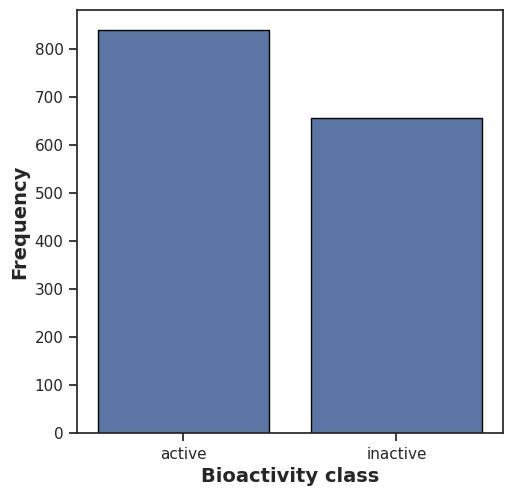

In [33]:
plt.figure(figsize=(5.5, 5.5))

sns.countplot(x='bioactivity_class', data=df_2class, edgecolor='black')

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('Frequency', fontsize=14, fontweight='bold')

plt.savefig('plot_bioactivity_class.pdf')

### **Scatter plot of MW versus LogP**

It can be seen that the 2 bioactivity classes are spanning similar chemical spaces as evident by the scatter plot of MW vs LogP.

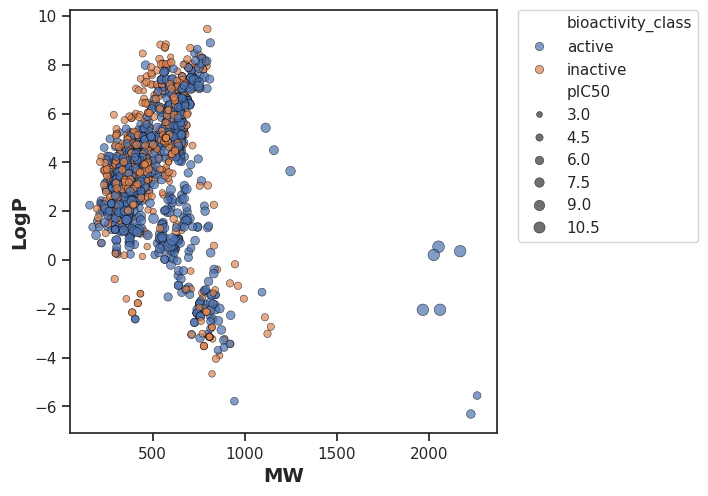

In [34]:
plt.figure(figsize=(5.5, 5.5))

sns.scatterplot(x='MW', y='LogP', data=df_2class, hue='bioactivity_class', size='pIC50', edgecolor='black', alpha=0.7)

plt.xlabel('MW', fontsize=14, fontweight='bold')
plt.ylabel('LogP', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0)
plt.savefig('plot_MW_vs_LogP.pdf')

### **Box plots**

#### **pIC50 value**

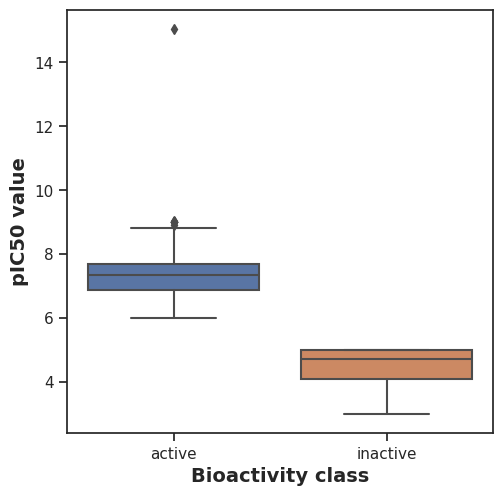

In [ ]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'pIC50', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('pIC50 value', fontsize=14, fontweight='bold')

plt.savefig('plot_ic50.pdf')

**Statistical analysis | Mann-Whitney U Test**

In [ ]:
def mannwhitney(descriptor, verbose=False):
  # https://machinelearningmastery.com/nonparametric-statistical-significance-tests-in-python/
  from numpy.random import seed
  from numpy.random import randn
  from scipy.stats import mannwhitneyu

# seed the random number generator
  seed(1)

# actives and inactives
  selection = [descriptor, 'bioactivity_class']
  df = df_2class[selection]
  active = df[df.bioactivity_class == 'active']
  active = active[descriptor]

  selection = [descriptor, 'bioactivity_class']
  df = df_2class[selection]
  inactive = df[df.bioactivity_class == 'inactive']
  inactive = inactive[descriptor]

# compare samples
  stat, p = mannwhitneyu(active, inactive)
  #print('Statistics=%.3f, p=%.3f' % (stat, p))

# interpret
  alpha = 0.05
  if p > alpha:
    interpretation = 'Same distribution (fail to reject H0)'
  else:
    interpretation = 'Different distribution (reject H0)'

  results = pd.DataFrame({'Descriptor':descriptor,
                          'Statistics':stat,
                          'p':p,
                          'alpha':alpha,
                          'Interpretation':interpretation}, index=[0])
  filename = 'mannwhitneyu_' + descriptor + '.csv'
  results.to_csv(filename)

  return results

In [ ]:
mannwhitney('pIC50')

,Descriptor,Statistics,p,alpha,Interpretation
0,pIC50,85789.0,2.417003e-69,0.05,Different distribution (reject H0)


#### **MW**

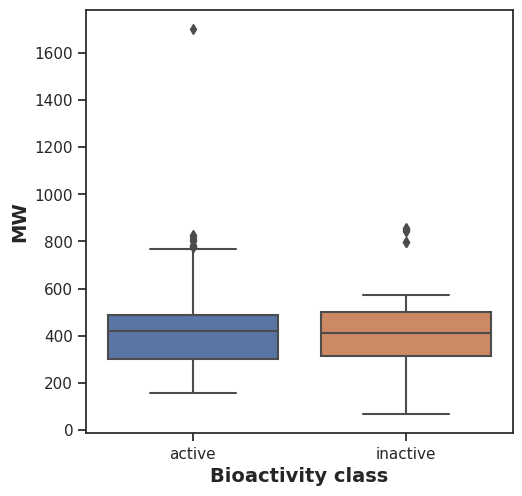

In [ ]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'MW', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('MW', fontsize=14, fontweight='bold')

plt.savefig('plot_MW.pdf')

In [ ]:
mannwhitney('MW')

,Descriptor,Statistics,p,alpha,Interpretation
0,MW,41210.0,0.489626,0.05,Same distribution (fail to reject H0)


#### **LogP**

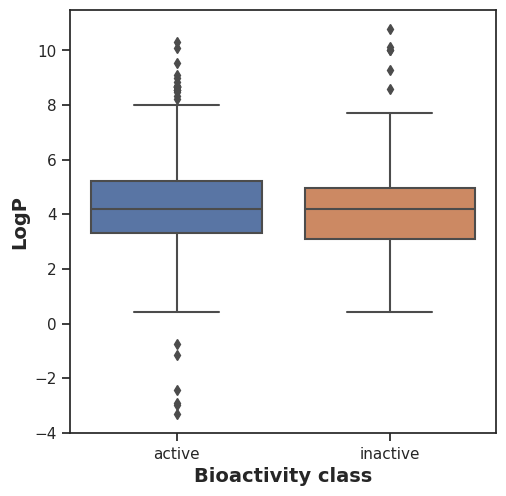

In [ ]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'LogP', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('LogP', fontsize=14, fontweight='bold')

plt.savefig('plot_LogP.pdf')

**Statistical analysis | Mann-Whitney U Test**

In [ ]:
mannwhitney('LogP')

,Descriptor,Statistics,p,alpha,Interpretation
0,LogP,44190.5,0.595064,0.05,Same distribution (fail to reject H0)


#### **NumHDonors**

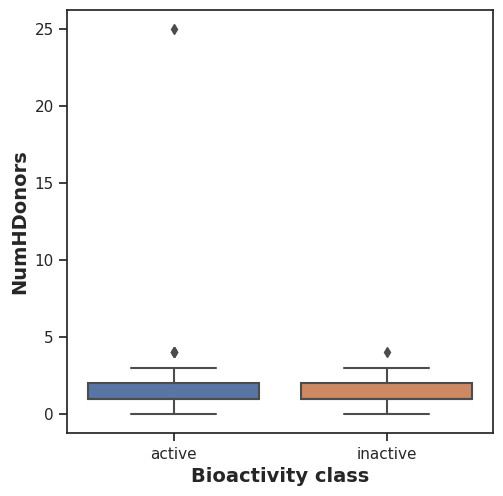

In [ ]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'NumHDonors', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('NumHDonors', fontsize=14, fontweight='bold')

plt.savefig('plot_NumHDonors.pdf')

**Statistical analysis | Mann-Whitney U Test**

In [ ]:
mannwhitney('NumHDonors')

,Descriptor,Statistics,p,alpha,Interpretation
0,NumHDonors,43200.0,0.889232,0.05,Same distribution (fail to reject H0)


#### **NumHAcceptors**

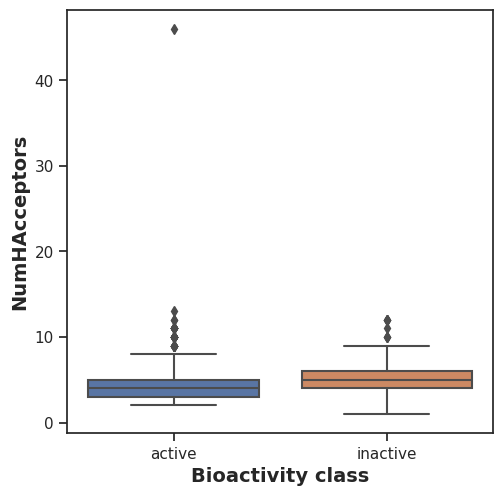

In [ ]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'NumHAcceptors', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('NumHAcceptors', fontsize=14, fontweight='bold')

plt.savefig('plot_NumHAcceptors.pdf')

In [ ]:
mannwhitney('NumHAcceptors')

,Descriptor,Statistics,p,alpha,Interpretation
0,NumHAcceptors,35209.0,0.00128,0.05,Different distribution (reject H0)


#### **Interpretation of Statistical Results**

##### **Box Plots**

###### **pIC50 values**

Taking a look at pIC50 values, the **actives** and **inactives** displayed ***statistically significant difference***, which is to be expected since threshold values (``IC50 < 1,000 nM = Actives while IC50 > 10,000 nM = Inactives``, corresponding to ``pIC50 > 6 = Actives and pIC50 < 5 = Inactives``) were used to define actives and inactives.

###### **Lipinski's descriptors**

Of the 4 Lipinski's descriptors (MW, LogP, NumHDonors and NumHAcceptors), only LogP exhibited ***no difference*** between the **actives** and **inactives** while the other 3 descriptors (MW, NumHDonors and NumHAcceptors) shows ***statistically significant difference*** between **actives** and **inactives**.

## **Zip files**

In [35]:
! zip -r results.zip . -i *.csv *.pdf

  adding: covid19_04_bioactivity_data_3class_pIC50.csv (deflated 77%)
  adding: plot_MW_vs_LogP.pdf (deflated 3%)
  adding: plot_bioactivity_class.pdf (deflated 37%)
  adding: STAT3_04_bioactivity_data_3class_pIC50.csv (deflated 77%)
  adding: STAT3_03_bioactivity_data_curated.csv (deflated 83%)
